# Superfermion Stabilizer Backend Benchmark

| Engine | Implementation |
|--------|----------------|
| Superfermion | Rust Aaronson-Gottesman tableau (H/S/Sdg/X/Y/Z/CX/CZ/SWAP), O(n) gate updates |
| Qiskit Aer | C++ stabilizer method (`AerSimulator(method='stabilizer')`) |

**Scope**: Clifford circuits only (the stabilizer representation is exact for them).
Non-Clifford gates are rejected with a clean error (tested in section 6); the
statevector/MPS backends cover those.

**Methodology**

- Same Clifford circuit on both engines, built once outside the timed region
  (simulation time only; Aer's transpilation stays inside its `run()` call as part
  of its execution path).
- Correctness before speed: TVD of SF stabilizer samples against the **exact**
  statevector distribution, threshold = 4-sigma of the expected multinomial noise,
  `4 * sqrt(K / (2*pi*N))` (same gate as `benchmark_master.ipynb`).
- Large-n structure checks: GHZ(100) sample split and exact tableau expectation
  values against independently computed numpy references.
- Timing: per-size warmup + medians, 15 trials (n<=20) tapering to 5 (n=200);
  the same trial count is used for both engines at every point. Raw per-trial
  times go to the JSON.
- **Where Aer stops**: Aer's stabilizer scales worse than quadratic on this host
  (52 s/call at n=500 in `benchmark_master.ipynb`), so this notebook's ladder ends
  at n=200; the 512-1024 range is SF-only in `benchmark_clifford.ipynb`.

In [1]:
# -- Bootstrap: pin the fixed LOCAL build (added 2026-09-24) ----------------
# Numbers in this notebook must describe the fixed local build, not any
# globally installed wheel, so the repo is pinned ahead of site-packages.
import sys as _sys
import hashlib as _hashlib
from pathlib import Path as _Path
REPO = _Path(r"C:\Users\ASUS\OneDrive\Desktop\sfdocs\superfermion")
assert (REPO / 'superfermion' / '__init__.py').exists(), f'repo not found: {REPO}'
if str(REPO) not in _sys.path:
    _sys.path.insert(0, str(REPO))
import superfermion._sf_core as _sfcore
_core = _Path(_sfcore.__file__)
print('=' * 78)
print('ENGINE PROVENANCE - fixed local build pinned for this run')
print('=' * 78)
print(f'  engine : {_core.name}  md5 {_hashlib.md5(_core.read_bytes()).hexdigest().upper()}')
print()

import gc
import time
import json
import platform
import numpy as np
from statistics import median

import superfermion as sf
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

print(f"Python: {platform.python_version()}")
print(f"CPU: {platform.processor() or 'unknown'}")
print(f"OS: {platform.system()} {platform.release()}")
print(f"SF version: {sf.__version__}")

ENGINE PROVENANCE - fixed local build pinned for this run
  engine : _sf_core.cp313-win_amd64.pyd  md5 17B755C032D01D0C9711EA2B75751506



Python: 3.13.3
CPU: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
OS: Windows 11
SF version: 0.1.12


In [2]:
# ── helpers ───────────────────────────────────────────────────────────────────
def timed(fn):
    gc.disable()
    t0 = time.perf_counter()
    result = fn()
    elapsed = (time.perf_counter() - t0) * 1000
    gc.enable()
    return result, elapsed

def benchmark(fn, n_trials):
    times = []
    for _ in range(n_trials):
        _, t = timed(fn)
        times.append(round(t, 2))
    med = median(times)
    s = sorted(times)
    q1 = s[len(s)//4]
    q3 = s[3*len(s)//4]
    return med, times, q1, q3

def fmt(sf_ms, qk_ms):
    if sf_ms < qk_ms:
        return f'SF {qk_ms/sf_ms:.1f}x faster'
    return f'Aer {sf_ms/qk_ms:.2f}x faster'

def build_clifford_only(n):
    'The benchmark_master.ipynb Clifford circuit (H/S/CX brickwork, ~6 layers).'
    sc = sf.Circuit(n); qc = QuantumCircuit(n)
    for q in range(n):         sc.h(q);  qc.h(q)
    for q in range(0, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
    for q in range(n):         sc.s(q);  qc.s(q)
    for q in range(1, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
    for q in range(n):         sc.h(q);  qc.h(q)
    for q in range(0, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
    return sc, qc

def build_clifford_depth(n, depth):
    'H(all) / CX(even) / S(all) / CX(odd) repeated `depth` times.'
    sc = sf.Circuit(n); qc = QuantumCircuit(n)
    for _ in range(depth):
        for q in range(n):         sc.h(q);  qc.h(q)
        for q in range(0, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
        for q in range(n):         sc.s(q);  qc.s(q)
        for q in range(1, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
    return sc, qc

def build_ghz(n):
    sc = sf.Circuit(n); qc = QuantumCircuit(n)
    sc.h(0); qc.h(0)
    for i in range(1, n): sc.cx(0, i); qc.cx(0, i)
    return sc, qc

def exact_probs(sc, n):
    'Exact computational-basis probabilities in the shared LE key convention.'
    sv = np.array(sf.run(sc, device='cpu', shots=0).statevector)
    return {format(i, f'0{n}b'): float(p)
            for i, p in enumerate(np.abs(sv) ** 2) if p > 1e-15}

def tvd_vs_exact(cnt, probs, shots):
    keys = set(cnt) | set(probs)
    dist = 0.5 * sum(abs(cnt.get(k, 0) / shots - probs.get(k, 0.0)) for k in keys)
    expected = np.sqrt(len(probs) / (2 * np.pi * shots))
    return dist, expected, 4 * expected

def z_string_exact(sv, n, qubits):
    'Exact expectation of the Z-product on `qubits` from a statevector (numpy ref).'
    idx = np.arange(2 ** n)
    sign = np.ones(2 ** n)
    for q in qubits:
        sign *= (1 - 2 * ((idx >> q) & 1))
    return float(np.sum((np.abs(sv) ** 2) * sign))

def z_string_pauli(n, qubits):
    'Rust-format observable for the Z-product on `qubits` (LSB-indexed list).'
    paulis = [0] * n
    for q in qubits:
        paulis[q] = 3
    return [(paulis, 1.0, 0.0)]

print('Helpers defined.')

Helpers defined.


## 1. Correctness: TVD against the exact distribution

200,000-shot stabilizer samples of the n=10 and n=12 Clifford circuits versus the
**exact** statevector distribution. Gate: TVD < 4-sigma multinomial noise.

In [3]:
print('=' * 88)
print('TVD CORRECTNESS GATES (stabilizer samples vs exact statevector distribution)')
print('=' * 88)
tvd_results = {}
for n in (10, 12):
    sc, _ = build_clifford_only(n)
    probs = exact_probs(sc, n)
    shots_check = 200000
    cnt = sf.run(sc, device='cpu', method='stabilizer', shots=shots_check, seed=42).counts
    dist, expected, thr = tvd_vs_exact(cnt, probs, shots_check)
    tvd_results[n] = {'tvd': dist, 'expected': float(expected), 'threshold': float(thr),
                      'K': len(probs), 'shots': shots_check}
    print(f'n={n:2d} | K={len(probs):5d} outcomes | TVD={dist:.4f} '
          f'(expected~{expected:.4f}, 4-sigma thr={thr:.4f}) | {"PASS" if dist < thr else "FAIL"}')
    assert dist < thr, f'TVD gate failed at n={n}: {dist} >= {thr}'
print('All TVD gates passed.')

TVD CORRECTNESS GATES (stabilizer samples vs exact statevector distribution)
n=10 | K= 1024 outcomes | TVD=0.0281 (expected~0.0285, 4-sigma thr=0.1142) | PASS
n=12 | K= 4096 outcomes | TVD=0.0572 (expected~0.0571, 4-sigma thr=0.2284) | PASS
All TVD gates passed.


## 2. Large-n structure checks

- **GHZ(100)**: exactly two outcomes; each branch must be within 5-sigma of N/2.
- **Exact tableau expectation values**: the stabilizer state handle computes Pauli
  expectation values in O(n^2); these must match an independent numpy computation
  from the exact statevector at n=12, and the analytic GHZ values at n=256.

In [4]:
print('=' * 88)
print('STRUCTURE CHECKS')
print('=' * 88)

# GHZ(100) sample split
sc_g, _ = build_ghz(100)
cnt_g = sf.run(sc_g, device='cpu', method='stabilizer', shots=10000, seed=7).counts
print(f'GHZ(100): {len(cnt_g)} distinct outcomes: '
      f'{[v for _, v in sorted(cnt_g.items())]}')
assert len(cnt_g) == 2, 'GHZ must have exactly two outcomes'
N_g = sum(cnt_g.values())
sig = np.sqrt(N_g * 0.25)
for k, v in cnt_g.items():
    print(f'  {k[:12]}...{k[-8:]}: {v} ({v/N_g:.4f}) | dev from N/2 = {abs(v - N_g/2):.0f} (5sig={5*sig:.0f})')
    assert abs(v - N_g / 2) < 5 * sig, 'GHZ branch outside 5-sigma'

# exact tableau expval vs numpy reference (n=12)
n_e = 12
sc_e, _ = build_clifford_only(n_e)
sv_e = np.array(sf.run(sc_e, device='cpu', shots=0).statevector)
st_e = sf.run(sc_e, device='cpu', method='stabilizer', shots=0)
for qubits in ([0], [0, 1], [0, 1, 2], [3, 5]):
    ref = z_string_exact(sv_e, n_e, qubits)
    got = st_e.state.expectation(z_string_pauli(n_e, qubits))
    print(f'  n={n_e} <Z{",".join(map(str, qubits))}>: tableau={got:+.10f} numpy={ref:+.10f} '
          f'diff={abs(got-ref):.2e}')
    assert abs(got - ref) < 1e-9, 'tableau expval mismatch'

# analytic GHZ(256) values
n_big = 256
sc_b, _ = build_ghz(n_big)
st_b = sf.run(sc_b, device='cpu', method='stabilizer', shots=0)
z0 = st_b.state.expectation(z_string_pauli(n_big, [0]))
z01 = st_b.state.expectation(z_string_pauli(n_big, [0, 1]))
z_all = st_b.state.expectation(z_string_pauli(n_big, list(range(n_big))))
print(f'  GHZ({n_big}): <Z0>={z0:+.3e} (exact 0), <Z0Z1>={z01:.10f} (exact 1), '
      f'<Z...Z>={z_all:.10f} (exact 1)')
assert abs(z0) < 1e-9 and abs(z01 - 1) < 1e-9 and abs(z_all - 1) < 1e-9
print('All structure checks passed.')

STRUCTURE CHECKS
GHZ(100): 2 distinct outcomes: [5038, 4962]
  111111111111...11111111: 4962 (0.4962) | dev from N/2 = 38 (5sig=250)
  000000000000...00000000: 5038 (0.5038) | dev from N/2 = 38 (5sig=250)
  n=12 <Z0>: tableau=+0.0000000000 numpy=+0.0000000000 diff=0.00e+00
  n=12 <Z0,1>: tableau=+0.0000000000 numpy=+0.0000000000 diff=0.00e+00
  n=12 <Z0,1,2>: tableau=+0.0000000000 numpy=+0.0000000000 diff=0.00e+00
  n=12 <Z3,5>: tableau=+0.0000000000 numpy=+0.0000000000 diff=0.00e+00
  GHZ(256): <Z0>=+0.000e+00 (exact 0), <Z0Z1>=1.0000000000 (exact 1), <Z...Z>=1.0000000000 (exact 1)
All structure checks passed.


## 3. Timing ladder (Clifford circuit, 10k shots)

Same prebuilt circuit on both engines; per-size warmup; shared trial counts
(15/15/10/7/5). Aer's runtime grows super-linearly here - see the notes for why
the ladder stops at n=200.

In [5]:
ladder = [(10, 15), (20, 15), (50, 10), (100, 7), (200, 5)]
stab_results = {}

print('=' * 100)
print('STABILIZER TIMING LADDER (Clifford circuit, shots=10000)')
print('=' * 100)
print(f'{"n":>4s} {"trials":>6s} | {"SF med":>9s} {"SF [q1-q3]":>15s} | '
      f'{"Aer med":>9s} {"Aer [q1-q3]":>15s} | winner')

for n, trials in ladder:
    sc_n, qc_n = build_clifford_only(n)
    qc_m = qc_n.copy(); qc_m.measure_all()

    # per-size warmup
    sf.run(sc_n, device='cpu', method='stabilizer', shots=1000)
    AerSimulator(method='stabilizer').run(qc_m, shots=1000).result()

    sf_med, sf_times, sf_q1, sf_q3 = benchmark(
        lambda: sf.run(sc_n, device='cpu', method='stabilizer', shots=10000), trials)

    def run_aer():
        return AerSimulator(method='stabilizer').run(qc_m, shots=10000).result()

    qk_med, qk_times, qk_q1, qk_q3 = benchmark(run_aer, trials)

    stab_results[n] = {
        'sf_ms': sf_med, 'sf_all': sf_times, 'sf_iqr': [sf_q1, sf_q3],
        'qk_ms': qk_med, 'qk_all': qk_times, 'qk_iqr': [qk_q1, qk_q3],
        'trials': trials,
    }
    print(f'{n:4d} {trials:6d} | {sf_med:9.1f} [{sf_q1:6.1f}-{sf_q3:6.1f}] | '
          f'{qk_med:9.1f} [{qk_q1:6.1f}-{qk_q3:6.1f}] | {fmt(sf_med, qk_med)}')

STABILIZER TIMING LADDER (Clifford circuit, shots=10000)
   n trials |    SF med      SF [q1-q3] |   Aer med     Aer [q1-q3] | winner


  10     15 |       3.4 [   3.0-   3.5] |      96.2 [  91.9- 121.6] | SF 28.7x faster


  20     15 |      12.3 [  11.6-  16.9] |     239.5 [ 219.5- 261.4] | SF 19.5x faster


  50     10 |      15.8 [  14.0-  19.2] |     687.8 [ 670.0- 701.3] | SF 43.4x faster


 100      7 |      23.8 [  17.3-  24.9] |    2062.0 [2018.5-2338.1] | SF 86.6x faster


 200      5 |      29.2 [  27.7-  35.9] |    7808.7 [7746.6-7906.0] | SF 267.8x faster


## 4. Shots scaling (n=100)

Sampling cost vs state-evolution cost. 5 trials each, per-setting warmup.

In [6]:
n_shot = 100
shot_grid = [1000, 10000, 100000]
sc_s, qc_s = build_clifford_only(n_shot)
qc_sm = qc_s.copy(); qc_sm.measure_all()
sf.run(sc_s, device='cpu', method='stabilizer', shots=1000)
AerSimulator(method='stabilizer').run(qc_sm, shots=1000).result()

shot_results = {}
print('=' * 88)
print(f'SHOTS SCALING (n={n_shot} Clifford, 5 trials)')
print('=' * 88)
for shots in shot_grid:
    sf_med, sf_times, _, _ = benchmark(
        lambda: sf.run(sc_s, device='cpu', method='stabilizer', shots=shots), 5)
    qk_med, qk_times, _, _ = benchmark(
        lambda: AerSimulator(method='stabilizer').run(qc_sm, shots=shots).result(), 5)
    shot_results[shots] = {'sf_ms': sf_med, 'sf_all': sf_times, 'qk_ms': qk_med, 'qk_all': qk_times}
    print(f'shots={shots:7d} | SF {sf_med:8.2f} ms | Aer {qk_med:9.2f} ms | {fmt(sf_med, qk_med)}')

SHOTS SCALING (n=100 Clifford, 5 trials)


shots=   1000 | SF     4.73 ms | Aer    271.32 ms | SF 57.4x faster


shots=  10000 | SF    23.77 ms | Aer   2065.55 ms | SF 86.9x faster


shots= 100000 | SF   228.00 ms | Aer  19840.87 ms | SF 87.0x faster


## 5. Depth scaling (n=50)

H/CX/S brickwork repeated `depth` times. 5 trials, per-depth warmup.

In [7]:
n_dep = 50
depths = [1, 2, 4, 8, 16]
depth_results = {}

print('=' * 88)
print(f'DEPTH SCALING (n={n_dep} Clifford, shots=10000, 5 trials)')
print('=' * 88)
for d in depths:
    sc_d, qc_d = build_clifford_depth(n_dep, d)
    qc_dm = qc_d.copy(); qc_dm.measure_all()
    sf.run(sc_d, device='cpu', method='stabilizer', shots=1000)
    AerSimulator(method='stabilizer').run(qc_dm, shots=1000).result()

    sf_med, sf_times, _, _ = benchmark(
        lambda: sf.run(sc_d, device='cpu', method='stabilizer', shots=10000), 5)
    qk_med, qk_times, _, _ = benchmark(
        lambda: AerSimulator(method='stabilizer').run(qc_dm, shots=10000).result(), 5)
    depth_results[d] = {'sf_ms': sf_med, 'sf_all': sf_times, 'qk_ms': qk_med, 'qk_all': qk_times}
    n_gates = d * (n_dep + (n_dep - 1) + n_dep + (n_dep - 2))
    print(f'd={d:2d} (~{n_gates:5d} gates) | SF {sf_med:8.1f} ms | Aer {qk_med:9.1f} ms | {fmt(sf_med, qk_med)}')

DEPTH SCALING (n=50 Clifford, shots=10000, 5 trials)


d= 1 (~  197 gates) | SF     18.6 ms | Aer     652.8 ms | SF 35.2x faster


d= 2 (~  394 gates) | SF     18.2 ms | Aer     675.1 ms | SF 37.1x faster


d= 4 (~  788 gates) | SF     20.1 ms | Aer     662.6 ms | SF 32.9x faster


d= 8 (~ 1576 gates) | SF     22.7 ms | Aer     679.6 ms | SF 29.9x faster


d=16 (~ 3152 gates) | SF     27.0 ms | Aer     711.7 ms | SF 26.4x faster


## 6. Non-Clifford rejection (documented behavior)

A Clifford-only backend must reject non-Clifford gates with a clean Python error
rather than silently truncating the state.

In [8]:
from superfermion.backends.stabilizer import is_clifford_circuit

good = sf.Circuit(4).h(0).cx(0, 1).s(2)
bad = sf.Circuit(4).h(0).rx(0.7, 1)
print('is_clifford_circuit(good):', is_clifford_circuit(good))
print('is_clifford_circuit(bad) :', is_clifford_circuit(bad))
assert is_clifford_circuit(good) and not is_clifford_circuit(bad)

try:
    sf.run(bad, device='cpu', method='stabilizer', shots=100)
    raise AssertionError('expected a refusal for the non-Clifford circuit')
except RuntimeError as e:
    print('refusal (first line):', str(e).splitlines()[0])
    assert 'non-Clifford' in str(e)
    print('PASS: clean rejection with guidance to use statevector/MPS')

is_clifford_circuit(good): True
is_clifford_circuit(bad) : False
refusal (first line): Circuit contains non-Clifford gates — cannot use method='stabilizer'.
PASS: clean rejection with guidance to use statevector/MPS


## Summary Plot

Saved benchmark_stabilizer_results.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_4172\3326183975.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


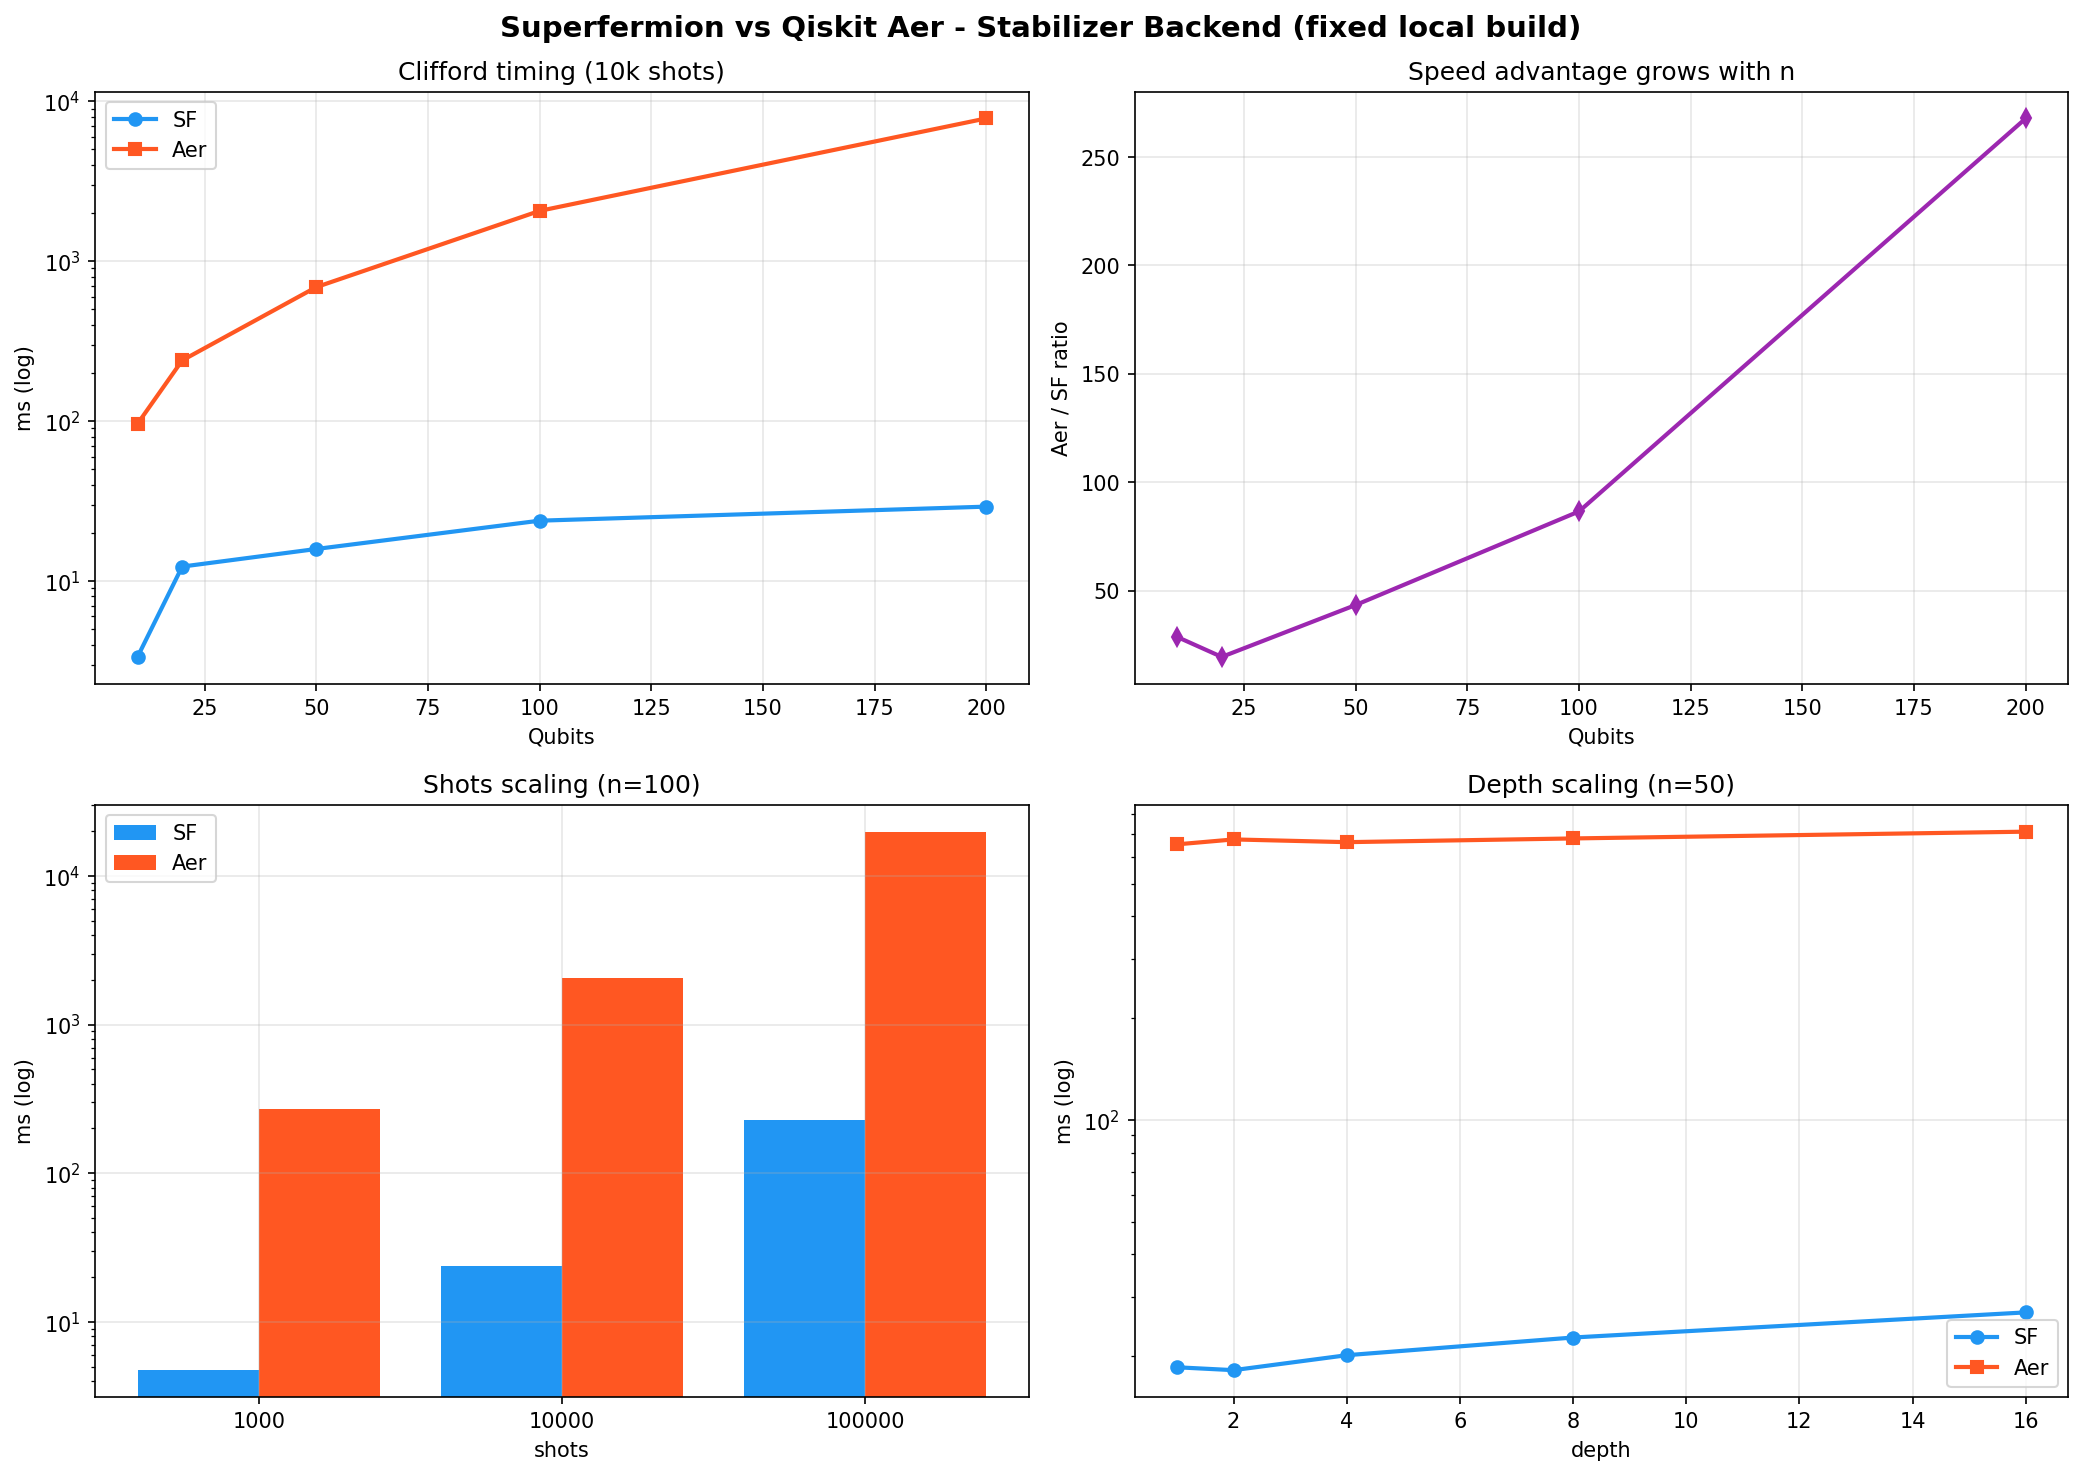

In [9]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superfermion vs Qiskit Aer - Stabilizer Backend (fixed local build)',
             fontsize=14, fontweight='bold')

ax = axes[0, 0]
ns = sorted(stab_results)
ax.semilogy(ns, [stab_results[n]['sf_ms'] for n in ns], 'o-', label='SF', color='#2196F3', lw=2)
ax.semilogy(ns, [stab_results[n]['qk_ms'] for n in ns], 's-', label='Aer', color='#FF5722', lw=2)
ax.set_xlabel('Qubits'); ax.set_ylabel('ms (log)')
ax.set_title('Clifford timing (10k shots)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ns2 = sorted(stab_results)
ax.plot(ns2, [stab_results[n]['qk_ms']/stab_results[n]['sf_ms'] for n in ns2],
        'd-', color='#9C27B0', lw=2)
ax.set_xlabel('Qubits'); ax.set_ylabel('Aer / SF ratio')
ax.set_title('Speed advantage grows with n')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sh = sorted(shot_results)
x = np.arange(len(sh))
ax.bar(x - 0.2, [shot_results[s]['sf_ms'] for s in sh], 0.4, label='SF', color='#2196F3')
ax.bar(x + 0.2, [shot_results[s]['qk_ms'] for s in sh], 0.4, label='Aer', color='#FF5722')
ax.set_xticks(x); ax.set_xticklabels([str(s) for s in sh])
ax.set_yscale('log')
ax.set_xlabel('shots'); ax.set_ylabel('ms (log)')
ax.set_title(f'Shots scaling (n={n_shot})')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ds = sorted(depth_results)
ax.semilogy(ds, [depth_results[d]['sf_ms'] for d in ds], 'o-', label='SF', color='#2196F3', lw=2)
ax.semilogy(ds, [depth_results[d]['qk_ms'] for d in ds], 's-', label='Aer', color='#FF5722', lw=2)
ax.set_xlabel('depth'); ax.set_ylabel('ms (log)')
ax.set_title(f'Depth scaling (n={n_dep})')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_stabilizer_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_stabilizer_results.png')

from IPython.display import Image, display
display(Image('benchmark_stabilizer_results.png'))

In [10]:
summary = {
    'platform': {
        'engine_md5': _hashlib.md5(_core.read_bytes()).hexdigest().upper(),
        'python': platform.python_version(),
        'cpu': platform.processor() or 'unknown',
        'os': f'{platform.system()} {platform.release()}',
        'run_date': time.strftime('%Y-%m-%d %H:%M:%S'),
        'sf_version': sf.__version__,
    },
    'tvd_gates': {str(k): v for k, v in tvd_results.items()},
    'timing_ladder': {str(k): v for k, v in stab_results.items()},
    'shots_scaling': {str(k): v for k, v in shot_results.items()},
    'depth_scaling': {str(k): v for k, v in depth_results.items()},
    'structure': {
        'ghz100_branches': {k: v for k, v in cnt_g.items()},
        'ghz256_z0': z0, 'ghz256_z0z1': z01, 'ghz256_zall': z_all,
    },
}
with open('benchmark_stabilizer_data.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved benchmark_stabilizer_data.json')
print(f'  engine md5 : {summary["platform"]["engine_md5"]}')

Saved benchmark_stabilizer_data.json
  engine md5 : 17B755C032D01D0C9711EA2B75751506


## Methodology Notes

- **Clifford scope**: exact for H/S/Sdg/X/Y/Z/CX/CZ/SWAP circuits; the 1024-qubit
  tableau cap and the 512-1024 scaling are covered in `benchmark_clifford.ipynb`.
- **Correctness-first**: every timing point sits behind the TVD gate (section 1) and
  the structure/expectation checks (section 2). The observable used for the
  structure checks is the exact tableau expectation, verified against numpy.
- **Where Aer wins / what is not measured**: Aer's stabilizer is a mature C++
  implementation and wins on ecosystem tooling (transpilers, noise-aware passes);
  this notebook measures raw simulation time only, on one host, single process.
  Aer's super-linear growth is why the ladder stops at n=200 - the n=500 point
  (52 s/call) was measured in `benchmark_master.ipynb` on the same build.
- **Trial counts**: 15/15/10/7/5 (both engines, identical at each n); 5 at the
  shots/depth galleries. Medians reported, raw trials in the JSON.